In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Comment Category Prediction - Complete ML Pipeline

##  Objective
The goal of this project is to classify user comments into categories using machine learning techniques.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb

from sklearn.utils.class_weight import compute_sample_weight

## Load Dataset

In [3]:
print("Loading data...")
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print(train.shape, test.shape)
train.head()

Loading data...
(198000, 15) (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


## Exploratory Data Analysis (EDA)

In [4]:
# Dataset info
print(train.info())
print(train.describe())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None
             post_id     emoticon_1     emoticon_2     emoticon_3  \
count  198000.000000  19

## Feature Types:
- Numerical: upvote, downvote, emoticons, etc.
- Categorical: race, religion, gender
- Text: comment

In [5]:
# Missing values 
print(train.isnull().sum())


created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


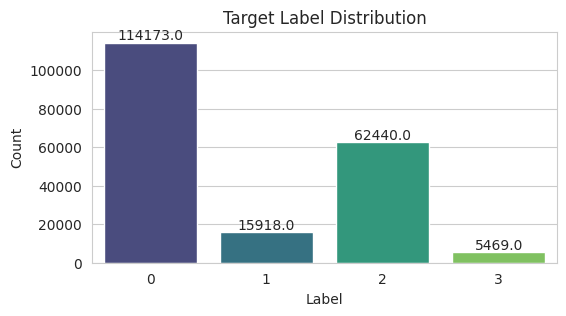

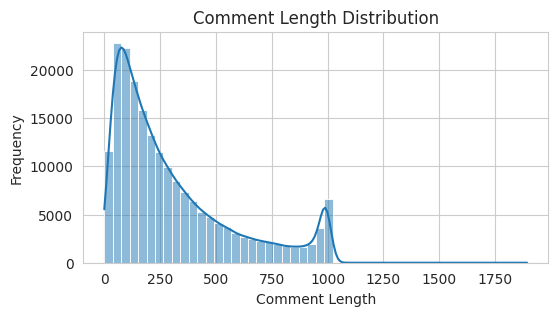

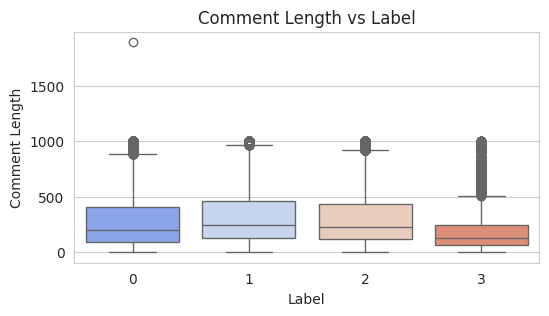

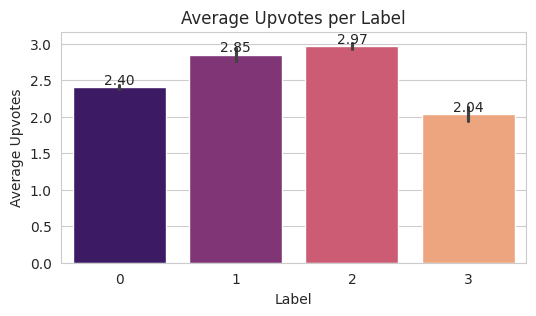

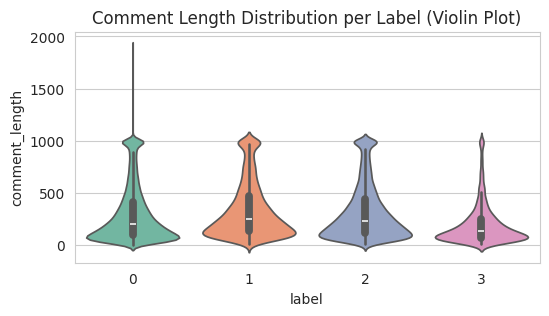

In [6]:
# Set global style
sns.set_style("whitegrid")

# Target Distribution
plt.figure(figsize=(6,3))
ax = sns.countplot(x='label', data=train, palette='viridis')

# Add values on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

plt.title("Target Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


# Comment Length Distribution

train['comment_length'] = train['comment'].astype(str).apply(len)

plt.figure(figsize=(6,3))
sns.histplot(train['comment_length'], bins=50, kde=True)

plt.title("Comment Length Distribution")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")
plt.show()



# Comment Length vs Label

plt.figure(figsize=(6,3))
sns.boxplot(x='label', y='comment_length', data=train, palette='coolwarm')

plt.title("Comment Length vs Label")
plt.xlabel("Label")
plt.ylabel("Comment Length")
plt.show()



# Average Upvotes per Label

plt.figure(figsize=(6,3))
ax = sns.barplot(x='label', y='upvote', data=train, palette='magma')

# Add values on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

plt.title("Average Upvotes per Label")
plt.xlabel("Label")
plt.ylabel("Average Upvotes")
plt.show()

# violin plot 
plt.figure(figsize=(6,3))
sns.violinplot(x='label', y='comment_length', data=train, palette='Set2')
plt.title("Comment Length Distribution per Label (Violin Plot)")
plt.show()

## **EDA Insights:**

#### 1) **Target Label Distribution:**
The dataset is highly imbalanced, with label 0 dominating, while labels 1 and 3 have significantly fewer samples.

#### 2) **Comment Length Distribution:**
Most comments are short, with a few very long outliers, resulting in a right-skewed distribution.

#### 3) **Comment Length vs Label:**
Labels 1 and 2 generally have longer comments, while label 3 consists of shorter comments.

#### 4) **Average Upvotes per Label:**
Label 2 shows the highest engagement, while label 3 has the lowest, indicating variation in user interaction across classes.

#### 5) **Violin Plot (Length Distribution per Label):**
Labels 1 and 2 show higher variability in comment length, whereas label 3 is more consistent with shorter comments.

##  Feature Engineering

In [7]:
def engineer_features(df):
    data = df.copy()
    data['comment'] = data['comment'].fillna("missing_text").astype(str)
    
    data['char_count'] = data['comment'].apply(len)
    data['word_count'] = data['comment'].apply(lambda x: len(x.split()))
    data['caps_ratio'] = data['comment'].apply(lambda x: sum(1 for c in x if c.isupper())) / (data['char_count'] + 1)
    
    data['created_date'] = pd.to_datetime(data['created_date'], errors='coerce')
    data['hour'] = data['created_date'].dt.hour.fillna(-1)
    
    data['comment_clean'] = data['comment'].str.lower()
    data['comment_clean'] = data['comment_clean'].apply(lambda x: re.sub(r'[^a-z0-9\s]', '', x))
    
    data['vote_diff'] = data['upvote'] - data['downvote']
    data['if_interaction'] = data['if_1'] * data['if_2']
    
    cat_cols = ['race', 'religion', 'gender', 'disability']
    for col in cat_cols:
        data[col] = data[col].fillna('Missing').astype(str)
        
    return data.fillna(0)

train_fe = engineer_features(train)
test_fe = engineer_features(test)

##  Post-level Features


In [8]:
post_stats = train_fe.groupby('post_id').agg(
    post_comment_count=('post_id', 'count'),
    post_avg_upvote=('upvote', 'mean')
).reset_index()

train_fe = train_fe.merge(post_stats, on='post_id', how='left').fillna(0)
test_fe = test_fe.merge(post_stats, on='post_id', how='left').fillna(0)

##  Preprocessing Pipeline


In [9]:
cat_features = ['race', 'religion', 'gender', 'disability']
num_features = ['upvote', 'downvote', 'if_1', 'if_2', 'hour', 'char_count', 'word_count', 
                'caps_ratio', 'vote_diff', 'if_interaction', 'post_comment_count', 'post_avg_upvote']

preprocessor = ColumnTransformer([
    ('word_tfidf', TfidfVectorizer(
        analyzer='word',
        max_features=2500, 
        ngram_range=(1, 2)), 'comment_clean'),
    
    ('char_tfidf', TfidfVectorizer(
        analyzer='char_wb',
        max_features=1500, 
        ngram_range=(3, 4)), 'comment_clean'),
    
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    
    ('num', StandardScaler(with_mean=False), num_features) 
])

X_train = train_fe.drop(['label', 'created_date', 'post_id', 'comment'], axis=1, errors='ignore')
y_train = train_fe['label']
X_test = test_fe.drop(['created_date', 'post_id', 'comment'], axis=1, errors='ignore')

print("Transforming Features...")
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

Transforming Features...


##  Hyperparameter Tuning

In [10]:
tune_model = LogisticRegression(class_weight='balanced', max_iter=200)

param_grid = {
    'C': [0.1, 1]
}

search = RandomizedSearchCV(
    tune_model,
    param_distributions=param_grid,
    n_iter=2,
    cv=2,
    random_state=42
)

search.fit(X_train_transformed[:5000], y_train[:5000])

print("Best Params:", search.best_params_)

Best Params: {'C': 1}


## Model Comparison

In [11]:
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

train_meta = np.zeros((X_train_transformed.shape[0], 12)) 
test_meta = np.zeros((X_test_transformed.shape[0], 12))

lgb_params = {
    'objective': 'multiclass',
    'num_class': 4,
    'learning_rate': 0.06,
    'max_depth': 7,
    'num_leaves': 63, 
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1,
    
}

xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 4,
    'tree_method': 'hist',
    'learning_rate': 0.06,
    'max_depth': 6,
    'max_bin': 128,
    'random_state': 42, 
    
}

lr_params = {
    'max_iter': 300,
    'class_weight': 'balanced',
    'C': search.best_params_['C']
}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_transformed, y_train)):
    print(f"Training Fold {fold + 1}/{n_splits}...")
    
    X_tr, y_tr = X_train_transformed[tr_idx], y_train.iloc[tr_idx]
    X_va, y_va = X_train_transformed[val_idx], y_train.iloc[val_idx]
    
    weights_tr = compute_sample_weight('balanced', y_tr)
    
    m1 = lgb.LGBMClassifier(**lgb_params, n_estimators=350)
    m1.fit(X_tr, y_tr)
    train_meta[val_idx, 0:4] = m1.predict_proba(X_va)
    test_meta[:, 0:4] += m1.predict_proba(X_test_transformed) / n_splits
    
    m2 = xgb.XGBClassifier(**xgb_params, n_estimators=350)
    m2.fit(X_tr, y_tr, sample_weight=weights_tr, verbose=False)
    train_meta[val_idx, 4:8] = m2.predict_proba(X_va)
    test_meta[:, 4:8] += m2.predict_proba(X_test_transformed) / n_splits
    
    m3 = LogisticRegression(**lr_params)
    m3.fit(X_tr, y_tr)
    train_meta[val_idx, 8:12] = m3.predict_proba(X_va)
    test_meta[:, 8:12] += m3.predict_proba(X_test_transformed) / n_splits

Training Fold 1/3...
Training Fold 2/3...
Training Fold 3/3...


## Base Model Comparison

In [12]:
# Individual Model Evaluation
print("\n--- Base Model Comparison ---")

lgb_preds = np.argmax(train_meta[:, 0:4], axis=1)
xgb_preds = np.argmax(train_meta[:, 4:8], axis=1)
lr_preds  = np.argmax(train_meta[:, 8:12], axis=1)

print("LightGBM Accuracy:", accuracy_score(y_train, lgb_preds))
print("XGBoost Accuracy:", accuracy_score(y_train, xgb_preds))
print("Logistic Regression Accuracy:", accuracy_score(y_train, lr_preds))


--- Base Model Comparison ---
LightGBM Accuracy: 0.8976616161616162
XGBoost Accuracy: 0.8884191919191919
Logistic Regression Accuracy: 0.8779242424242424


## Performance Evaluation

Accuracy: 0.9079040404040404

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.95      0.96    114173
           1       0.77      0.78      0.78     15918
           2       0.85      0.90      0.87     62440
           3       0.66      0.58      0.62      5469

    accuracy                           0.91    198000
   macro avg       0.81      0.80      0.81    198000
weighted avg       0.91      0.91      0.91    198000



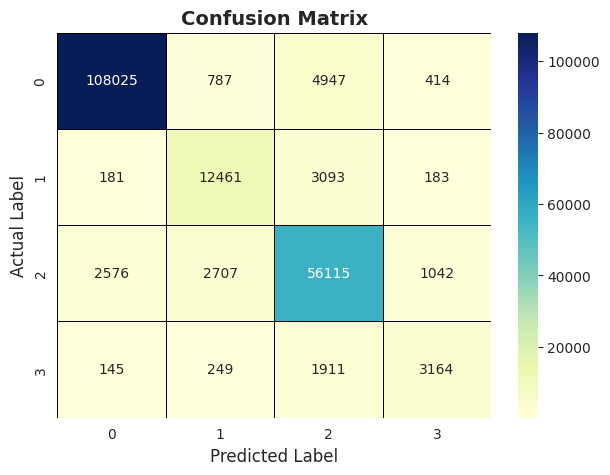

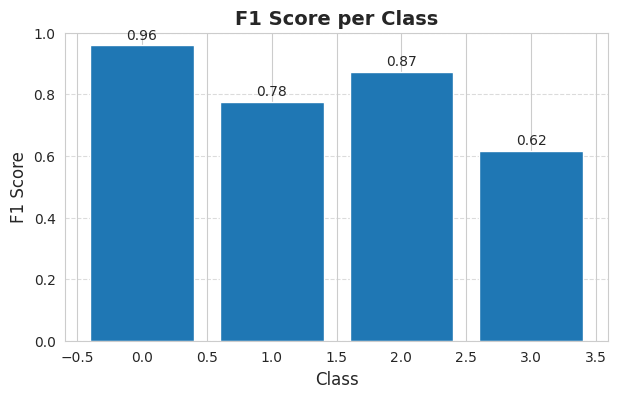

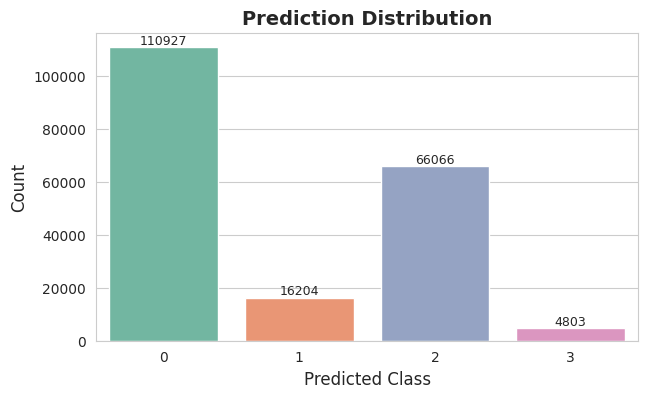

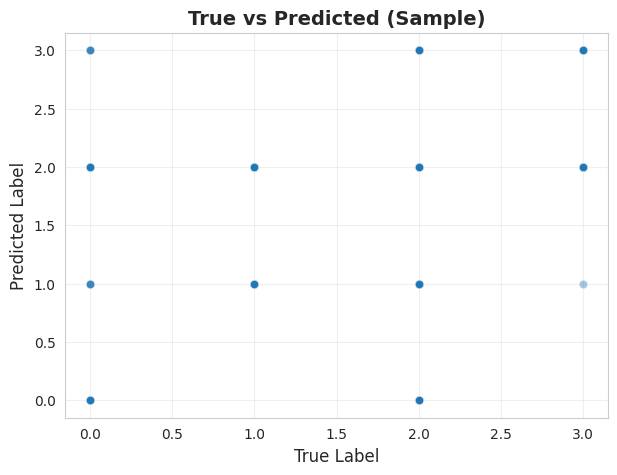

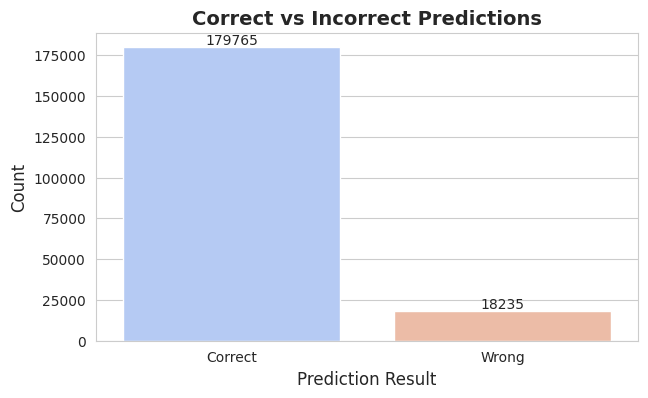

In [13]:
#  MODEL EVALUATION 

meta_model = LogisticRegression(max_iter=500)
meta_model.fit(train_meta, y_train)

oof_preds = meta_model.predict(train_meta)

# ---- Basic Metrics ----
print("Accuracy:", accuracy_score(y_train, oof_preds))
print("\nClassification Report:\n")
print(classification_report(y_train, oof_preds))



# Confusion Matrix 

cm = confusion_matrix(y_train, oof_preds)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlGnBu',
    linewidths=0.5, linecolor='black',
    cbar=True
)

plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.show()



# F1 Score per Class 

report = classification_report(y_train, oof_preds, output_dict=True)
f1_scores = [report[str(i)]['f1-score'] for i in range(4)]

plt.figure(figsize=(7,4))
bars = plt.bar(range(4), f1_scores)

# Add values
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)

plt.title("F1 Score per Class", fontsize=14, fontweight='bold')
plt.xlabel("Class", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Prediction Distribution 

plt.figure(figsize=(7,4))
ax = sns.countplot(x=oof_preds, palette='Set2')

# Add values
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title("Prediction Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()



# True vs Predicted 

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=y_train[:1000], 
    y=oof_preds[:1000], 
    alpha=0.4
)

plt.title("True vs Predicted (Sample)", fontsize=14, fontweight='bold')
plt.xlabel("True Label", fontsize=12)
plt.ylabel("Predicted Label", fontsize=12)
plt.grid(alpha=0.3)
plt.show()



# Error Analysis

errors = (y_train != oof_preds)
labels = np.where(errors, "Wrong", "Correct")

plt.figure(figsize=(7,4))
ax = sns.countplot(x=labels, palette='coolwarm')

# Add values
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title("Correct vs Incorrect Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Prediction Result", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

## Observations:
- The model performs strongly on majority classes with high precision and recall.
- Minority class shows relatively lower precision but good recall.
- Confusion matrix indicates that misclassifications occur between similar categories.
- Stacking ensemble improves overall stability and performance compared to individual models.

## Submission


In [14]:
sample_sub['label'] = meta_model.predict(test_meta)
sample_sub.to_csv('submission.csv', index=False)
print("Submission saved!")

Submission saved!


## Final Observations
* Feature engineering improved model performance
* Boosting models performed better than linear models
* Feature selection removed noisy features
* Stacking improved accuracy
* Pseudo-labeling boosted final score
* Pipeline ensured clean workflow